## _Tracking Metrics_

- _The notebook is supplementary to `analysisScripts/tracks.py`._
- _Just investigate what is done in `analysisScripts/tracks.py`._

In [1]:
from ipython_tools import handler

handler.style()

Welcome to JupyROOT 6.26/14


In [2]:
import uproot
import src.custom_functions as cf

In [3]:

%matplotlib inline

In [4]:
file_path = "mixed/mixed_ntuple.root"
ntuple_file = uproot.open(file_path)

In [5]:
# Names of classes
# ntuple_file.classnames()

In [6]:
# List of contents with keys
# ntuple_file.keys()

In [7]:
# Get TTrees with square brackets
t_MCpions = ntuple_file["MCpions"]
t_pions = ntuple_file["pions"]

In [8]:
# Keys in a TTree
# t_pions.keys()
# t_pions.values()
# t_pions.typenames()
# t_pions.show()

In [9]:
# Single TBranch in a TTree
# t_pions["px"].array()  # Awkward array (default)
# t_pions["px"].array(library="np")  # NumPy ndarray
# t_pions["px"].array(library="pd")  # Pandas series

In [10]:
# mom = t_pions.arrays(["px", "py", "pz"], library="pd")
# mom.head()

In [70]:
# Get TTrees as DataFrames
MCpions = t_MCpions.arrays(library="pd")
pions = t_pions.arrays(library="pd")

- _Definition of variables not stored in the `DataFrame` (nTuples)_

In [71]:
# MCPoins Colums
print(MCpions.columns.tolist())

['__experiment__', '__run__', '__event__', '__production__', '__candidate__', '__ncandidates__', '__eventType__', '__weight__', 'mcPX', 'mcPY', 'mcPZ', 'mcX', 'mcY', 'mcZ', 'mcPDG', 'isPrimarySignal', 'seenInCDC', 'seenInSVD']


In [72]:
MCpions.query("isPrimarySignal==1").shape

(8522, 18)

In [73]:
MCpions.query("seenInSVD==1 or seenInCDC==1").shape

(8603, 18)

In [74]:
MCpions.query("isPrimarySignal==1 and (seenInSVD==1 or seenInCDC==1)").shape

(7828, 18)

In [75]:
print(pions.columns.tolist())

['__experiment__', '__run__', '__event__', '__production__', '__candidate__', '__ncandidates__', '__eventType__', '__weight__', 'mcPX', 'mcPY', 'mcPZ', 'mcX', 'mcY', 'mcZ', 'mcPDG', 'px', 'py', 'pz', 'x', 'y', 'z', 'isPrimarySignal', 'seenInCDC', 'seenInSVD', 'isSignal', 'mcSecPhysProc', 'isCloneTrack', 'isTrackFlippedAndRefitted', 'charge']


In [76]:
pions.query("abs(mcPDG)==211 and (isPrimarySignal==0 or isPrimarySignal==1)").shape

(7787, 29)

In [77]:
pions.query("abs(mcPDG)==211 and (isSignal==0 or isSignal==1)").shape

(7787, 29)

In [78]:
pions.query(
    "abs(mcPDG)==211 and mcSecPhysProc==0 and (isSignal==0 or isSignal==1)"
).shape

(7481, 29)

In [79]:
pions.query("abs(mcPDG)==211 and mcSecPhysProc==0").shape

(7481, 29)

In [80]:
pions.query("abs(mcPDG)==211 and mcSecPhysProc==0 and isCloneTrack==0").shape

(7194, 29)

In [81]:
pions.query(
    "abs(mcPDG)==211 and mcSecPhysProc==0 and (isSignal==0 or isSignal==1) and isCloneTrack==0"
).shape

(7194, 29)

## _Derived Variables_

In [23]:
# new variables to MCpions DataFrame
MCpions["mcP"] = cf.p(MCpions["mcPX"], MCpions["mcPY"], MCpions["mcPZ"])
MCpions["mcPT"] = cf.pt(MCpions["mcPX"], MCpions["mcPY"])
MCpions["mcCosTheta"] = cf.costheta(MCpions["mcPX"], MCpions["mcPY"], MCpions["mcPZ"])
MCpions["mcPhi"] = cf.phi(MCpions["mcPX"], MCpions["mcPY"])

In [24]:
# new variables to pions DataFrame
pions["p"] = cf.p(pions["px"], pions["py"], pions["pz"])
pions["pt"] = cf.pt(pions["px"], pions["py"])
pions["cosTheta"] = cf.costheta(pions["px"], pions["py"], pions["pz"])
pions["phi"] = cf.phi(pions["px"], pions["py"])

pions["mcP"] = cf.p(pions["mcPX"], pions["mcPY"], pions["mcPZ"])
pions["mcPT"] = cf.pt(pions["mcPX"], pions["mcPY"])
pions["mcCosTheta"] = cf.costheta(pions["mcPX"], pions["mcPY"], pions["mcPZ"])
pions["mcPhi"] = cf.phi(pions["mcPX"], pions["mcPY"])

## _Figure of Merits (FoMs)_

- $\text{Finding Charge Efficiency}$ = $\frac{\text{matched MC with correct charge}}{\text{all primary MC}} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch}}}{\text{MCpions}_{\text{tightMatch}}}$

- $\text{Finding Efficiency}$ = $\frac{\text{matched MC}}{\text{all primary MC}} \Leftrightarrow \frac{\text{pions}_{\text{looseMatch}}}{\text{MCpions}_{\text{tightMatch}}}$

- $\text{Charge Efficiency}$ = $\frac{\text{matched MC with correct charge}}{\text{matched MC}}  \Leftrightarrow \frac{\text{pions}_{\text{tightMatch}}}{\text{pions}_{\text{looseMatch}}}$

- $\text{Charge Asymmetry}$ = $\frac{\text{matched}^+ \text{ with correct charge} - \text{matched}^- \text{ with correct charge}}{\text{matched}^+ \text{ with correct charge} + \text{matched}^- \text{ with correct charge}} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch, plus}} - \text{pions}_{\text{tightMatch, minus}}}{\text{pions}_{\text{tightMatch, plus}} + \text{pions}_{\text{tightMatch, minus}}}$

- $\text{Fake Rate}$ = $\frac{\text{PR not related to MC}}{\text{all PR}} \Leftrightarrow \frac{\text{pions}_{\text{fake}}}{\text{pions}}$

- $\text{Clone Rate}$ = $\frac{\text{clones}}{\text{PR related to MC}} \Leftrightarrow \frac{\text{pions}_{\text{clone}}}{\text{pions}_{\text{wRelationToMC}}}$

- $\text{Flip Right}$ = $\frac{\text{matched MC with correct charge} \land (\text{isTrackFlippedAndRefitted} = 1)}{(\text{isTrackFlippedAndRefitted} = 1) \land \text{matched MC}} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch, flipRefit}}}{\text{pions}_{\text{looseMatch, flipRefit}}}$

- $\text{Flip Wrong}$ = $\frac{\text{matched MC with wrong charge} \land (\text{isTrackFlippedAndRefitted} = 1)}{(\text{isTrackFlippedAndRefitted} = 1) \land \text{matched MC}} \Leftrightarrow \frac{\text{pions}_{\text{wrongMatch, flipRefit}}}{\text{pions}_{\text{looseMatch, flipRefit}}}$

- $\text{Flipping Efficiency}$ = $\frac{\text{matched MC with correct charge} \land (\text{isTrackFlippedAndRefitted} = 1)}{[(\text{isTrackFlippedAndRefitted} = 1) \land \text{matched MC}] \lor \text{matched MC with wrong charge}} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch, flipRefit}}}{(\text{pions}_{\text{looseMatch, flipRefit}}) \lor (\text{pions}_{\text{wrongMatch}})} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch, flipRefit}}}{\text{pions}_{\text{toBeFlipped}}}$

- $\text{Flipped Fraction}$ = $\frac{\text{isTrackFlippedAndRefitted} = 1}{\text{all PR}} \Leftrightarrow \frac{\text{pions}_{\text{flipRefit}}}{\text{pions}}$

### _Definition of Lists used for FOMs_

- _**For MC Pions**_

In [25]:
MCpions_tightMatch = MCpions.query("isPrimarySignal==1")
MCpions_tightMatch_plus = MCpions.query("isPrimarySignal==1 and mcPDG==211")
MCpions_tightMatch_minus = MCpions.query("isPrimarySignal==1 and mcPDG==-211")

- _**For Reco Pions**_

In [26]:
pions_tightMatch = pions.query("isPrimarySignal==1 and isCloneTrack==0")
pions_tightMatch_plus = pions_tightMatch.query("charge>0.")
pions_tightMatch_minus = pions_tightMatch.query("charge<0.")

In [27]:
pions_looseMatch = pions.query(
    "abs(mcPDG)==211 and mcSecPhysProc==0 and (isSignal==0 or isSignal==1) and isCloneTrack==0"
)
pions_wrongMatch = pions_looseMatch.query("isSignal==0")

In [28]:
pions_fake = pions.query("isSignal!=0 and isSignal!=1")
pions_clone = pions.query("isCloneTrack==1")
pions_wRelationToMC = pions.query("isSignal==0 or isSignal==1")

In [29]:
pions_flipRefit = pions.query("isTrackFlippedAndRefitted==1")
pions_tigthMatch_flipRefit = pions_tightMatch.query("isTrackFlippedAndRefitted==1")

pions_tigthMatch_flipRefit_plus = pions_tightMatch_plus.query(
    "isTrackFlippedAndRefitted==1"
)
pions_tigthMatch_flipRefit_minus = pions_tightMatch_minus.query(
    "isTrackFlippedAndRefitted==1"
)

pions_looseMatch_flipRefit = pions_looseMatch.query("isTrackFlippedAndRefitted==1")
pions_wrongMatch_flipRefit = pions_wrongMatch.query("isTrackFlippedAndRefitted==1")

pions_toBeFlipped = pions_looseMatch.query(
    "isTrackFlippedAndRefitted==1 or isSignal==0"
)

- _Same as above, with the additional requirement for track of being inside the **detector acceptance**  (seen in CDC or SVD)_
    - _These are actually the most interesting lists for pure tracking studies_

In [30]:
# detector acceptance
seen = "seenInSVD==1 or seenInCDC==1"

- _**For MC Pions within Detector Acceptance**_

In [31]:
MCpions_tightMatch_seen = MCpions_tightMatch.query(seen)
MCpions_tightMatch_plus_seen = MCpions_tightMatch_plus.query(seen)
MCpions_tightMatch_minus_seen = MCpions_tightMatch_minus.query(seen)

- _**For Reco Pions within Detector Acceptance**_

In [32]:
pions_tightMatch_seen = pions_tightMatch.query(seen)
pions_tightMatch_plus_seen = pions_tightMatch_plus.query(seen)
pions_tightMatch_minus_seen = pions_tightMatch_minus.query(seen)

In [33]:
pions_looseMatch_seen = pions_looseMatch.query(seen)
pions_wrongMatch_seen = pions_wrongMatch.query(seen)

In [34]:
pions_clone_seen = pions_clone.query(seen)
pions_wRelationToMC_seen = pions_wRelationToMC.query(seen)

In [35]:
pions_flipRefit_seen = pions_flipRefit.query(seen)
pions_tigthMatch_flipRefit_seen = pions_tigthMatch_flipRefit.query(seen)
pions_tigthMatch_flipRefit_plus_seen = pions_tigthMatch_flipRefit_plus.query(seen)
pions_tigthMatch_flipRefit_minus_seen = pions_tigthMatch_flipRefit_minus.query(seen)

In [36]:
pions_looseMatch_flipRefit = pions_looseMatch_flipRefit.query(seen)
pions_wrongMatch_flipRefit = pions_wrongMatch_flipRefit.query(seen)
pions_toBeFlipped_seen = pions_toBeFlipped.query(seen)

## _Figure of Merits (FoMs)_

- Finding Charge Efficiency = Matched MC with correct charge / all primary MC

- Finding Efficiency = Matched MC / all primary MC

- Charge Efficiency = Matched MC with Correct Charge / Matched MC

- Charge Asymmetry = (Matched_plus with correct charge - Matched_minus with correct charge) / (Matched_plus with correct charge + Matched_minus with correct charge) if (matched_plus + matched_minus) != 0 else 0.

- Fake Rate = PR not Related to MC / all PR

- Clone Rate = Clones / PR Related to MC

- Flip Right = (matched MC with correct charge && isTrackFlippedAndRefitted == 1) / (isTrackFlippedAndRefitted ==1 && matched MC)

- Flip Wrong = (matched MC with wrong charge && isTrackFlippedAndRefitted == 1) / (isTrackFlippedAndRefitted ==1 && matched MC)

- Flipping Efficiency = (Matched MC with correct charge && isTrackFlippedAndRefitted==1) / ((isTrackFlippedAndRefitted ==1 && matched MC) || (matched MC with wrong charge))

- Flipped Fraction = (isTrackFlippedAndRefitted==1) / all PR

### _Variables to be tested_

- _`x`: $cos\theta$, `y`: $p$_

**N.B.**: for efficiency plots we need the MC information, while for asymmetries, fake rate, clone rate, flipping info we need the reconstructed information.

In [37]:
x_v, y_v = "mcCosTheta", "mcPT"
x_l, y_l = r"cos$\theta_{MC}$", "p$_{t,MC}$ [GeV/c]"
x_b = 6
y_b = [
    0.0,
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0,
    1.5,
    2.0,
]
x_r, y_r = (-1.0, 1.0), (0.0, 1.0)

- In order to factor out the geometrical acceptance (= evaluate the pure tracking efficiency), use _`seen`_ lists as numerator and denominator in the efficiencies definitions

## _Finding Efficiency_

- _Mind the `seen` flag (in `tracking_metrics.py` the `seen` flag is `True`._

In [38]:
# let counts, and calculate the ratio
len(pions_looseMatch_seen)

7194

In [39]:
len(MCpions_tightMatch_seen)

7828

In [40]:
len(pions_looseMatch_seen) / len(MCpions_tightMatch_seen)

0.9190086867654573

ratio (overall): 0.919009 +- 0.003084


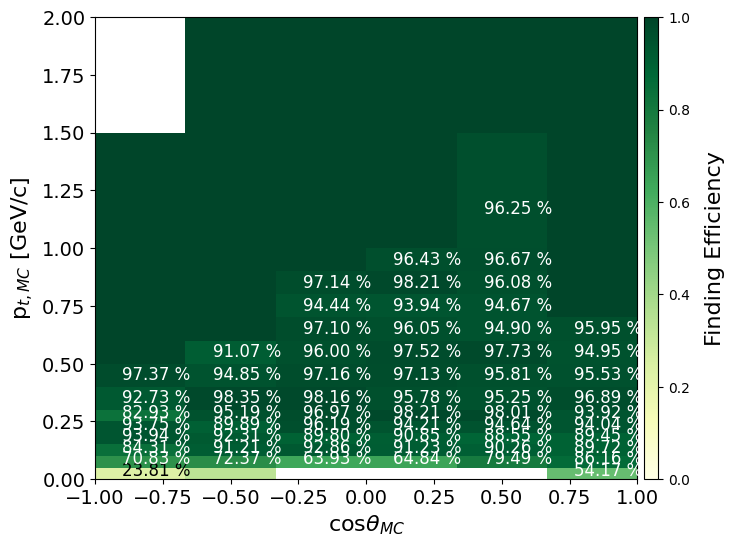

In [41]:
# finding efficiency
a = cf.ratio_2D(
    pions_looseMatch_seen,
    MCpions_tightMatch_seen,
    x_var=x_v,
    y_var=y_v,
    x_label=x_l,
    y_label=y_l,
    cbar_label="Finding Efficiency",
    bins_x=x_b,
    bins_y=y_b,
    range_x=x_r,
    range_y=y_r,
    cmap="YlGn",
    vmin=0,
    vmax=1,
    color_text="white",
    color_text2="black",
    threshold=0.5,
    size_text=12,
    figsize=(7, 6),
    savefig=True,
    figname="FE",
    savefigerr=True,
    errfigname="err_FE",
    offsetx=0.2,
    offsety=0.2,
    percent=True,
    closefig=False,
);